In [30]:
import os
from PIL import Image
import torch
from torch.utils.data import Dataset
import xml.etree.ElementTree as ET
from train_test_helper import get_cell_counts, optimize_split
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

class BCCDDataset(Dataset):
    def __init__(self, image_dir, anno_dir, indices, transforms=None):
        """
        image_dir : folder containing the .jpg files
        anno_dir  : folder containing the .xml files
        indices   : list of integer indices for this split
                    (these are positions into the full sorted list of images)
        transforms: optional transforms
        """

    
        self.image_dir = image_dir
        self.anno_dir = anno_dir
        self.indices = list(indices)          # make sure it is a list
        self.transforms = transforms
        
        # Class name → integer label
        # 0 is reserved for background by PyTorch detection models
        self.class_to_label = {
            "RBC": 1,
            "WBC": 2,
            "Platelets": 3
        }
        
        # Get a sorted list of all image file names so that
        # integer indices always point to the same image
        self.all_image_files = sorted([
            f for f in os.listdir(image_dir) if f.endswith(".jpg")
        ])
    def __len__(self):
        """
        Returns the number of images in this split.
        """
        return len(self.indices)

    def __getitem__(self, idx):
        """
        idx : position inside this split (0 to len(self)-1)
        
        Returns:
            image  : PIL Image (we will convert to tensor later)
            target : dictionary with 'boxes' and 'labels'
        """
        
        # 1. Convert the split position into the real image index
        real_idx = self.indices[idx]
        
        # 2. Get the image file name
        img_filename = self.all_image_files[real_idx]
        
        # 3. Build the full path and load the image
        img_path = os.path.join(self.image_dir, img_filename)
        image = Image.open(img_path).convert("RGB")
        
        # 4. Build the corresponding XML path
        #    "BloodImage_00000.jpg" → "BloodImage_00000.xml"
        xml_filename = img_filename.replace(".jpg", ".xml")
        xml_path = os.path.join(self.anno_dir, xml_filename)
        
        # 5. Parse the XML
        tree = ET.parse(xml_path)
        root = tree.getroot()
        
        boxes = []
        labels = []

        for obj in root.findall("object"):
            name = obj.find("name").text          # "RBC", "WBC", or "Platelets"
            
            # Convert class name to integer label
            label = self.class_to_label[name]
            
            bndbox = obj.find("bndbox")
            xmin = float(bndbox.find("xmin").text)
            ymin = float(bndbox.find("ymin").text)
            xmax = float(bndbox.find("xmax").text)
            ymax = float(bndbox.find("ymax").text)
            
            boxes.append([xmin, ymin, xmax, ymax])
            labels.append(label)
        
        # 6. Convert lists to tensors
        boxes = torch.as_tensor(boxes, dtype=torch.float32)    # shape [N, 4]
        labels = torch.as_tensor(labels, dtype=torch.int64)    # shape [N]
        
        # 7. Build the target dictionary
        target = {
            "boxes": boxes,
            "labels": labels
        }
        
        return image, target
    


In [31]:
jpg_dir = '../data/BCCD/JPEGImages/'
anno_dir = '../data/BCCD/Annotations/'
xml_data, rbc_counts, wbc_counts, platelet_counts = get_cell_counts(anno_dir)
train_idx, test_idx = train_test_split(np.arange(len(xml_data)), test_size=0.3, random_state=42)
train_idx, test_idx = optimize_split(rbc_counts, wbc_counts, platelet_counts, train_idx, test_idx,verbose=True, only_idx = True)
test_idx, val_idx = train_test_split(test_idx, test_size=0.5, random_state=42)
test_idx_f, val_idx = optimize_split(rbc_counts, wbc_counts, platelet_counts, test_idx, val_idx,verbose=True, only_idx = True)


Initial train loss: 0.3417
Initial test loss: 0.7890
Initial Combined Loss: 1.1307
START


100%|██████████| 9000/9000 [00:01<00:00, 6761.05it/s]



Final Train Loss: 0.0440
Final Test Loss: 0.1017
Final Combined Loss: 0.1457

Initial train loss: 0.4504
Initial test loss: 0.4738
Initial Combined Loss: 0.9243
START


100%|██████████| 9000/9000 [00:00<00:00, 9752.31it/s]


Final Train Loss: 0.2278
Final Test Loss: 0.2209
Final Combined Loss: 0.4487


254
Image size: (640, 480)
Boxes shape: torch.Size([15, 4])
Labels: tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3])
Number of objects: 15
Boxes:  tensor([[153., 309., 243., 394.],
        [131., 401., 224., 480.],
        [377., 176., 484., 285.],
        [486., 274., 575., 362.],
        [434.,   1., 516.,  74.],
        [481.,  55., 592., 154.],
        [ 90., 118., 184., 206.],
        [274., 137., 374., 230.],
        [515.,   1., 615.,  50.],
        [561., 132., 640., 231.],
        [589., 304., 640., 388.],
        [527., 392., 638., 480.],
        [271.,  18., 398., 114.],
        [234., 332., 369., 480.],
        [282., 296., 324., 339.]])
BloodImage_00264.jpg
BloodImage_00264.xml


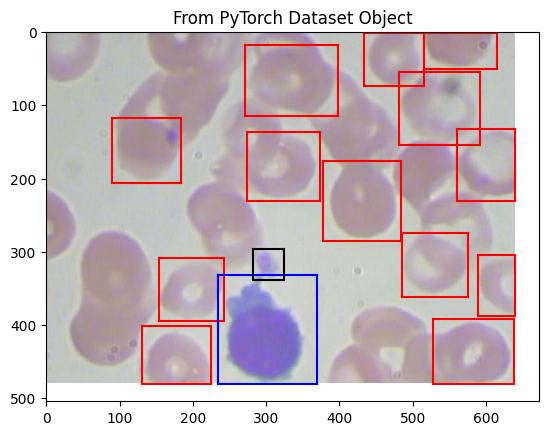

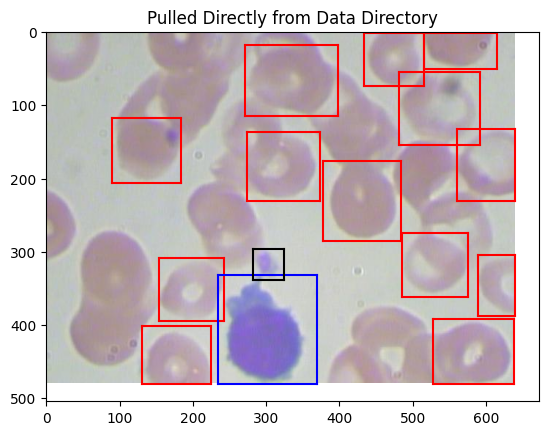

In [62]:
idx= 1
bc_data = BCCDDataset(jpg_dir, anno_dir, train_idx)
print(len(bc_data.indices))
image, target = bc_data[idx]

print("Image size:", image.size)
print("Boxes shape:", target["boxes"].shape)
print("Labels:", target["labels"])
print("Number of objects:", len(target["labels"]))
print("Boxes: ", target["boxes"])
plt.imshow(image)
plt.title("From PyTorch Dataset Object")
labels = target["labels"]
boxes = target['boxes']

for ix, item in enumerate(labels):
    cell_type = labels[ix]
    box = boxes[ix]
    if cell_type == 1:
        color = 'red'
    elif cell_type == 2:
        color = "blue"
    else:
        color = "black"
    xmin = box[0]
    ymin = box[1]
    xmax = box[2]
    ymax = box[3]
    plt.plot([xmin, xmax],[ymin, ymin], color=color)
    plt.plot([xmax, xmax],[ymin, ymax], color=color)
    plt.plot([xmin, xmax],[ymax, ymax], color=color)
    plt.plot([xmin, xmin],[ymax, ymin], color=color)

#sanity check
all_image_files = sorted([f for f in os.listdir(jpg_dir) if f.endswith(".jpg")])
real_idx = train_idx[idx]
pulled_img = all_image_files[real_idx]
print(pulled_img)
img_path = os.path.join(jpg_dir, pulled_img)
image = Image.open(img_path).convert("RGB")
plt.figure()
plt.imshow(image)
plt.title("Pulled Directly from Data Directory")
all_xml_files = sorted([f for f in os.listdir(anno_dir) if f.endswith(".xml")])
xml_path = os.path.join(anno_dir, all_xml_files[real_idx])
print(all_xml_files[real_idx])
tree = ET.parse(xml_path)
root = tree.getroot()

boxes = []
labels = []

for obj in root.findall("object"):
    name = obj.find("name").text          # "RBC", "WBC", or "Platelets"
    
    # Convert class name to integer label
    label = bc_data.class_to_label[name]
    bndbox = obj.find("bndbox")
    xmin = float(bndbox.find("xmin").text)
    ymin = float(bndbox.find("ymin").text)
    xmax = float(bndbox.find("xmax").text)
    ymax = float(bndbox.find("ymax").text)
    
    boxes.append([xmin, ymin, xmax, ymax])
    labels.append(label)
for ix, item in enumerate(labels):
    cell_type = labels[ix]
    box = boxes[ix]
    if cell_type == 1:
        color = 'red'
    elif cell_type == 2:
        color = "blue"
    else:
        color = "black"
    xmin = box[0]
    ymin = box[1]
    xmax = box[2]
    ymax = box[3]
    plt.plot([xmin, xmax],[ymin, ymin], color=color)
    plt.plot([xmax, xmax],[ymin, ymax], color=color)
    plt.plot([xmin, xmax],[ymax, ymax], color=color)
    plt.plot([xmin, xmin],[ymax, ymin], color=color)
